## A MINI PROJECT ON DATA CLEANING AND VISUALIZING
#### STUDENT NAME: **ADENIJI OLUWASEUN DORCAS**
#### STUDENT ID: **SCA/APC3/DS/148**

### **PROJECT 1: VIZUALIZATION OF CAUSES OF DEATH USING COXCOMB PLOT**

In [1]:
import pandas as pd
from plotnine import *
import janitor
from lets_plot import *

LetsPlot.setup_html



<bound method LetsPlot.setup_html of <class 'lets_plot.LetsPlot'>>

In [2]:
raw_night_a = pd.read_excel ("raw_night_1854_1855.xlsx")
raw_night_b = pd.read_excel("raw_night_1855_1856.xlsx")

print (raw_night_a)
print (raw_night_b)

FileNotFoundError: [Errno 2] No such file or directory: 'raw_night_1854_1855.xlsx'

In [ ]:
raw_night2a = raw_night_a["Month"].str.split(" " , expand = True)

raw_night2b = raw_night_b["Month"].str.split(" " , expand = True)


raw_night3a = raw_night2a.rename(columns = {0 : "Months",
                             1 : "Year"})
raw_night3b = raw_night2b.rename(columns = {0 : "Months",
                             1 : "Year"})

raw_night4a = pd.concat([raw_night_a, raw_night3a], axis = 1)
raw_night4b = pd.concat([raw_night_b, raw_night3b], axis = 1)

raw_night5a = raw_night4a.drop(raw_night4a.columns[0], axis=1)
raw_night5b = raw_night4b.drop(raw_night4b.columns[0], axis=1)


In [ ]:
raw_night5a.head(10)

In [ ]:
raw_night5b

In [ ]:
#joining the two datasets together, 

raw_night = pd.concat([raw_night5a , raw_night5b])

print (raw_night)
print (raw_night.describe())
print (raw_night.isna().value_counts())

In [ ]:
raw_night1 = raw_night5a.pivot_longer(index = ["Avg Army Size", "Months", "Year"],
                          names_to = "Death_causes",
                          values_to = "Count",
                         dropna = True)
raw_night1 = raw_night1.round(0)
raw_night1

raw_night2 = raw_night5b.pivot_longer(index = ["Avg Army Size", "Months", "Year"],
                          names_to = "Death_causes",
                          values_to = "Count",
                         dropna = True)
raw_night2 = raw_night2.round(0)
raw_night2

In [ ]:
print (raw_night1.describe())
print (raw_night1.isna().value_counts())

In [ ]:
#to ensure the month appear in the right order for 1854-1855

ordered_month = ["Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec", "Jan", "Feb", "Mar"]
raw_night1["Months"] = pd.Categorical(
    raw_night1["Months"],
    categories = ordered_month,
    ordered = True)

raw_night1 = raw_night1.sort_values(["Year", "Months"]).reset_index(drop=True)
raw_night1.head(36)

In [ ]:
#to ensure the month appear in the right order for 1855-1856

ordered_month2 = ["Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec", "Jan", "Feb", "Mar"]
raw_night2["Months"] = pd.Categorical(
    raw_night2["Months"],
    categories = ordered_month2,
    ordered = True)

raw_night2 = raw_night2.sort_values(["Year", "Months"]).reset_index(drop=True)
raw_night2.head(36)

In [ ]:
#let's create  columns for causes the death in a year and find the rate which is often expressed per 1,000

raw_night1["rate"] = (raw_night1["Count"] / raw_night1["Avg Army Size"]) * 1000 * 12

raw_night1 = raw_night1.round(2)
raw_night1


raw_night2["rate"] = (raw_night2["Count"] / raw_night2["Avg Army Size"]) * 1000 * 12

raw_night2 = raw_night2.round(2)
raw_night2


In [ ]:
import numpy as np

In [ ]:
#I would need numpy package here because I want to use mathematical function "sqrt"

raw_night1["Radius"] = np.sqrt(raw_night1["rate"])

print (raw_night1.round(2))
print ("------------------------------------------------------------------")

raw_night2["Radius"] = np.sqrt(raw_night2["rate"])

print (raw_night2.round(2))

In [ ]:
order = [ "Other Causes", "Wounds","Disease Deaths"]
raw_night1["Death_causes"] = pd.Categorical(
    raw_night1["Death_causes"],
    categories = order,
    ordered = True)

raw_night2["Death_causes"] = pd.Categorical(
    raw_night2["Death_causes"],
    categories = order,
    ordered = True)

In [ ]:
#to visualize data

from lets_plot import *
LetsPlot.setup_html()

(ggplot (raw_night1, aes("Months", "Radius", fill = "Death_causes"))
 + geom_bar (stat = "identity", width=1, color="black", size=0.1)
 + coord_polar()
 + scale_fill_manual(values = ["#7c7973", "#d6bfba", "#bacad2"])
 + theme_minimal()
 + ggsize (1000, 800)
 + labs (x = "",
        y = "",
        title = "Nightingale's Coxcomb: Mortality Rates from April 1854 to March 1855")
 + theme (
     axis_text_y=element_blank(), 
        axis_ticks_y=element_blank())
)

In [ ]:
(ggplot (raw_night2, aes("Months", "Radius", fill = "Death_causes"))
 + geom_bar (stat = "identity", width=1, color="black", size=0.1)
 + coord_polar()
 + scale_fill_manual(values = ["#7c7973", "#d6bfba", "#bacad2"])
 + theme_minimal()
 + ggsize (1000, 800)
 + labs (x = "",
        y = "",
        title = "Nightingale's Coxcomb: Mortality Rates from April 1855 to March 1856")
 + theme (
     axis_text_y=element_blank(), 
        axis_ticks_y=element_blank())
)

The chart displayed above is a Nightingale Coxcomb Diagram which illustrates the causes of mortality in the British Army during the Crimean War. Each "petal" represents a month, with the area of the segments showing the number of deaths: blue for preventable diseases, pink for wounds sustained, and dark grey for all other causes. The dramatic reduction in the size of the diagram from 1854-1855 to 1885-1856 proves that sanitary reforms successfully saved lives by nearly eliminating disease-related deaths.

### PROJECT 2: ANALYZING TELCO CUSTOMER CHURN DATASET

In [ ]:
#IMPORT ALL LIBRARIES
import pandas as pd
import numpy as np
from plotnine import *


In [192]:
telco = pd.read_csv("C:/Users/Dell/Documents/SCA_PYTHON_DOCUMENT/mini project/mini project/telco/telco_customer_churn2.csv")

telco.head(10)

,customer_id,gender,senior_citizen,partner,DEPENDENTS,tenure,pho_ne_service,multi$ple_l@ines,int#e&rnet_service,onli!ne_secur^ity,...,device_protectio+n,TECH_SUP(PORT,st-rea(min(g_tv,streaming_movies,c!ontract,paperless_b%illing,paym#ent_*metho_d,mon^thly_char^ges,t-otal_c(harges,ch_u+rn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
5,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
6,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
7,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No
8,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No
9,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes


In [205]:
telco1 = telco.clean_names(remove_special = True)
telco1

,customer_id,gender,senior_citizen,partner,dependents_,tenure,pho_ne_service,multiple_l_ines,internet_service,online_security,...,device_protection,tech_sup_port,st_rea_min_g_tv,streaming_movies,contract,paperless_billing,payment_metho_d,monthly_charges,t_otal_c_harges_,ch_urn_
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7743,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7744,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7745,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7746,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [206]:
telco1.isna().value_counts()

customer_id  gender  senior_citizen  partner  dependents_  tenure  pho_ne_service  multiple_l_ines  internet_service  online_security  online_bac_kup  device_protection  tech_sup_port  st_rea_min_g_tv  streaming_movies  contract  paperless_billing  payment_metho_d  monthly_charges  t_otal_c_harges_  ch_urn_
False        False   False           False    False        False   False           False            False             False            False           False              False          False            False             False     False              False            False            False             False      7737
                                                                                                                                                                                                                                                                                           True              False        11
Name: count, dtype: int64

In [207]:
telco1.shape

(7748, 21)

In [208]:
telco1.size

162708

In [209]:
telco1.ndim

2

In [210]:
telco1.duplicated().value_counts()

False    7043
True      705
Name: count, dtype: int64

In [211]:
telco1 = telco.dropna()

telco1.drop_duplicates()

,customer_id,gender,senior_citizen,partner,DEPENDENTS,tenure,pho_ne_service,multi$ple_l@ines,int#e&rnet_service,onli!ne_secur^ity,...,device_protectio+n,TECH_SUP(PORT,st-rea(min(g_tv,streaming_movies,c!ontract,paperless_b%illing,paym#ent_*metho_d,mon^thly_char^ges,t-otal_c(harges,ch_u+rn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
5,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7743,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7744,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7745,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7746,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [212]:
telco1.columns

Index(['customer_id', 'gender', 'senior_citizen', 'partner', 'DEPENDENTS ',
       'tenure', 'pho_ne_service', 'multi$ple_l@ines', 'int#e&rnet_service',
       'onli!ne_secur^ity', '&onl!ine_ba^c@kup', 'device_protectio+n',
       'TECH_SUP(PORT', 'st-rea(min(g_tv', 'streaming_movies', 'c!ontract',
       'paperless_b%illing', 'paym#ent_*metho_d', 'mon^thly_char^ges',
       't-otal_c(harges ', 'ch_u+rn '],
      dtype='object')

In [214]:
telco2 = telco1.clean_names(remove_special = True)

telco2.head(10)

,customer_id,gender,senior_citizen,partner,dependents_,tenure,pho_ne_service,multiple_l_ines,internet_service,online_security,...,device_protection,tech_sup_port,st_rea_min_g_tv,streaming_movies,contract,paperless_billing,payment_metho_d,monthly_charges,t_otal_c_harges_,ch_urn_
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
5,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
6,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
7,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No
8,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No
9,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes


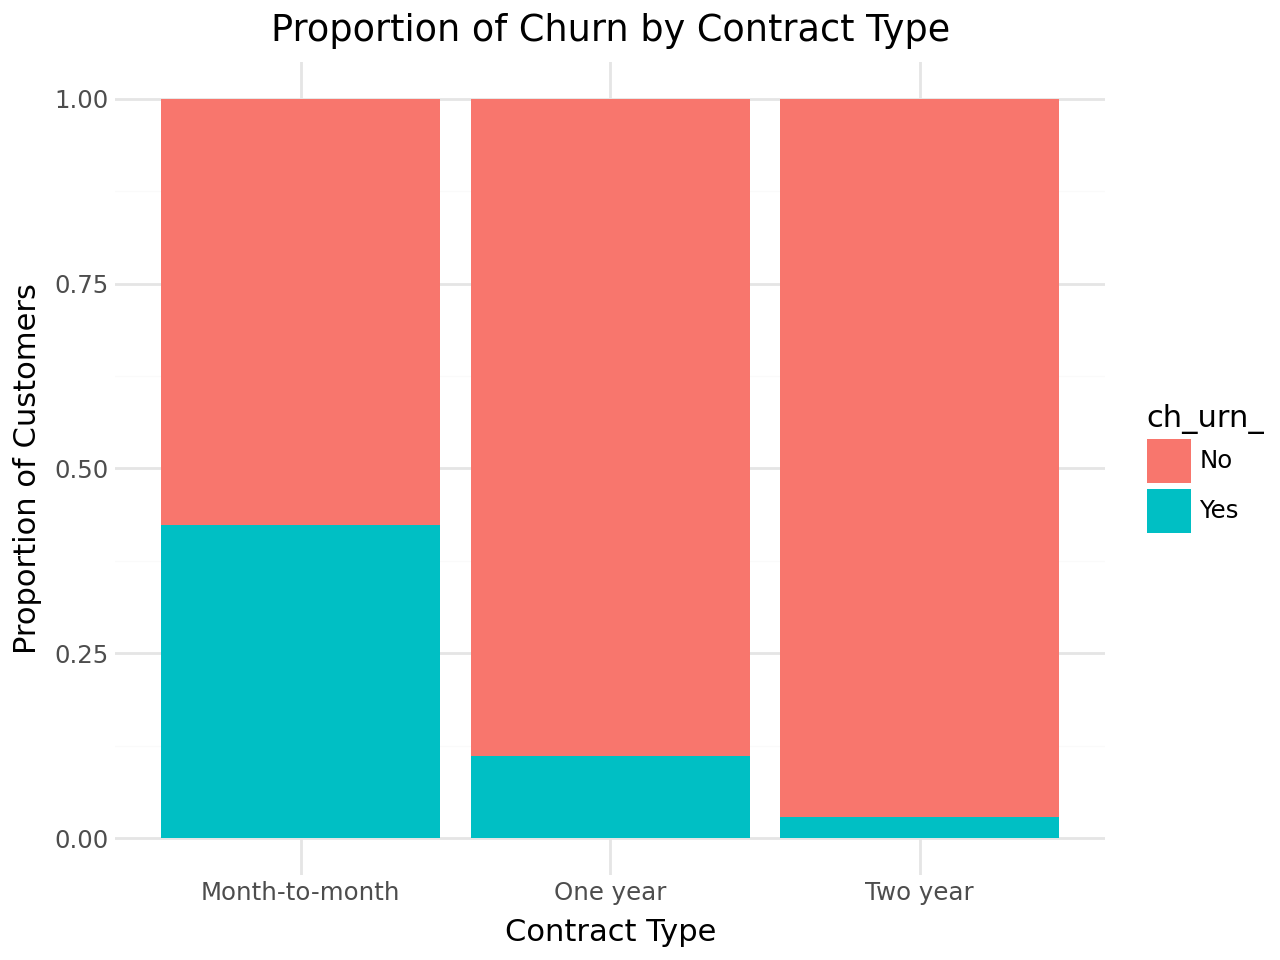

In [226]:
#Visualize using different charts

(ggplot(telco2, aes(x = "contract" , fill = "ch_urn_"))
 + geom_bar(position='fill')
    + labs(title='Proportion of Churn by Contract Type', 
           y='Proportion of Customers', 
           x='Contract Type')
    + theme_minimal()
)

                    

##### The churn section for Month-to-month is massive compared to the tiny slivers in long-term contracts. 
##### Contract type is the strongest predictor of churn

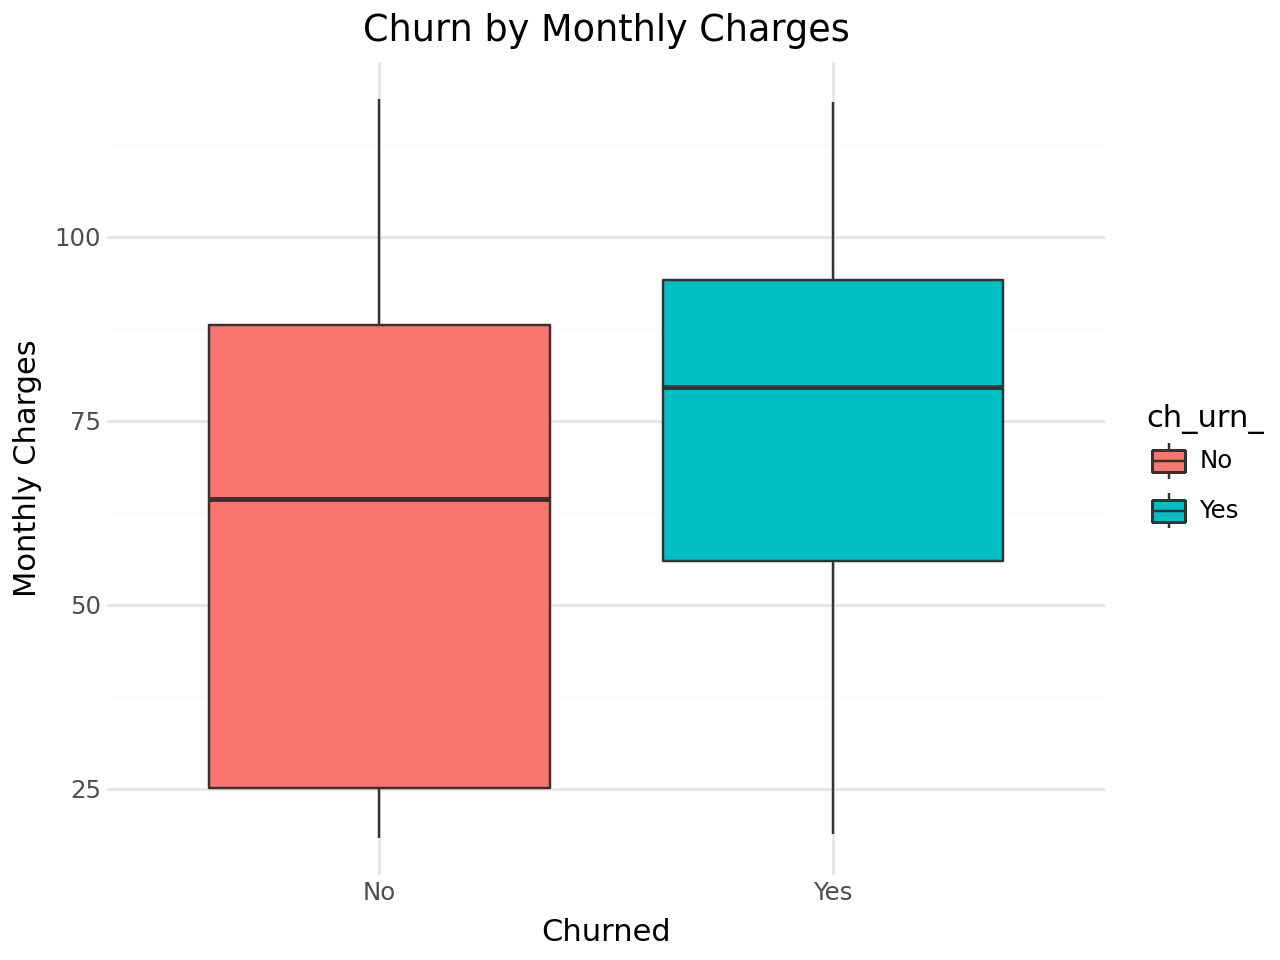

In [225]:
(ggplot(telco2, aes(x='ch_urn_', y='monthly_charges', fill='ch_urn_'))
 + geom_boxplot()
 + labs(title='Churn by Monthly Charges', 
        x='Churned', 
        y='Monthly Charges')
 + theme_minimal())

##### The "Yes" (churn) box has a higher median and sits higher on the Y-axis than the "No" (stayed) box.
I think customers who pay higher monthly fees are more likely to leave. This suggests that as the service becomes more expensive, customers become more price-sensitive and look for cheaper alternatives.

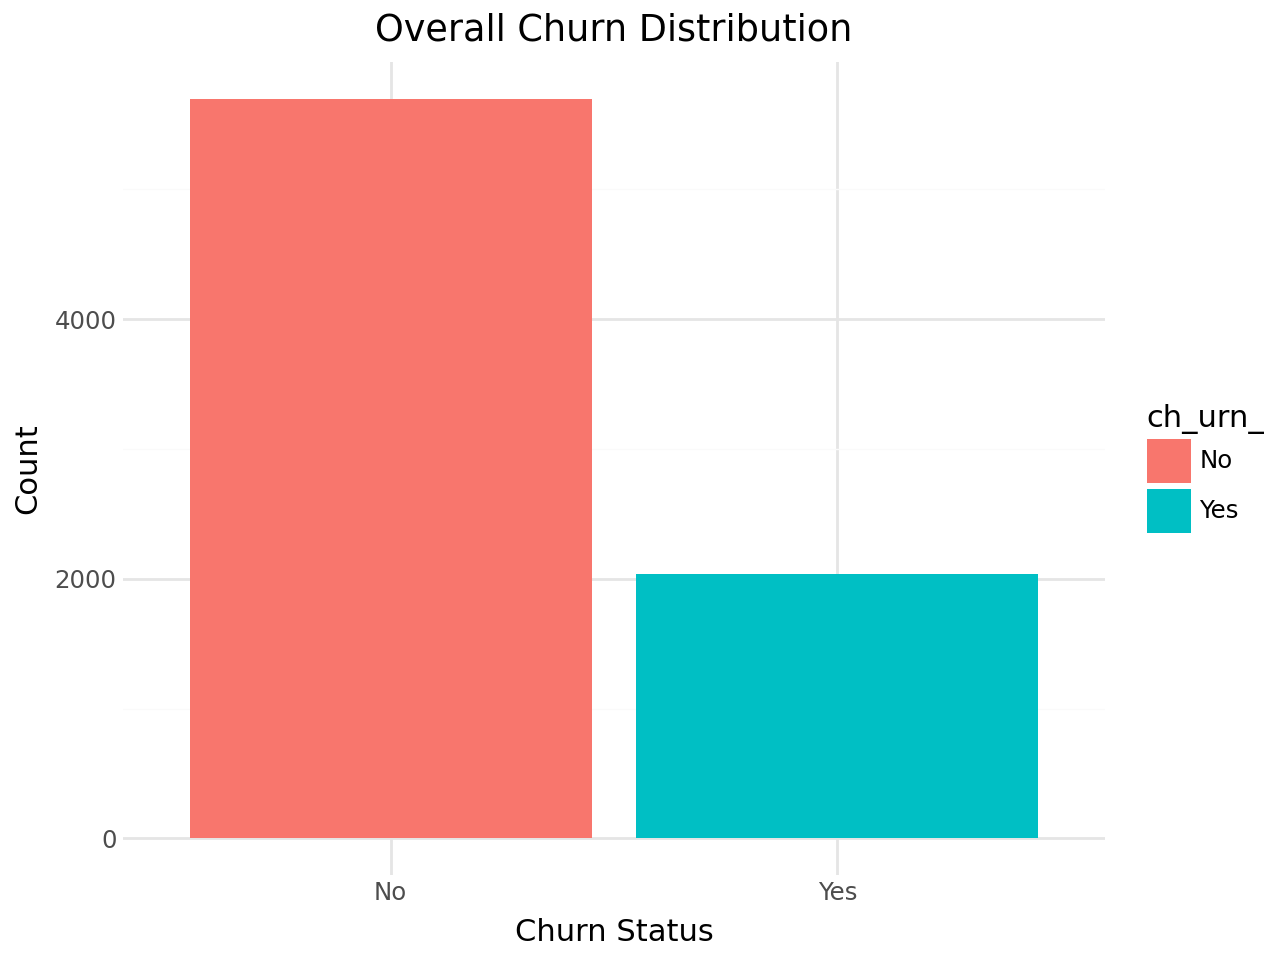

In [220]:
(ggplot(telco2, aes(x='ch_urn_', fill='ch_urn_'))
      + geom_bar()
      + theme_minimal()
      + labs(title='Overall Churn Distribution', 
             x='Churn Status', 
             y='Count'))

##### The Overall Churn distribution shows that roughly 27% of customers has churned, while 73% stayed. This is a significant issue that need quick intervention.

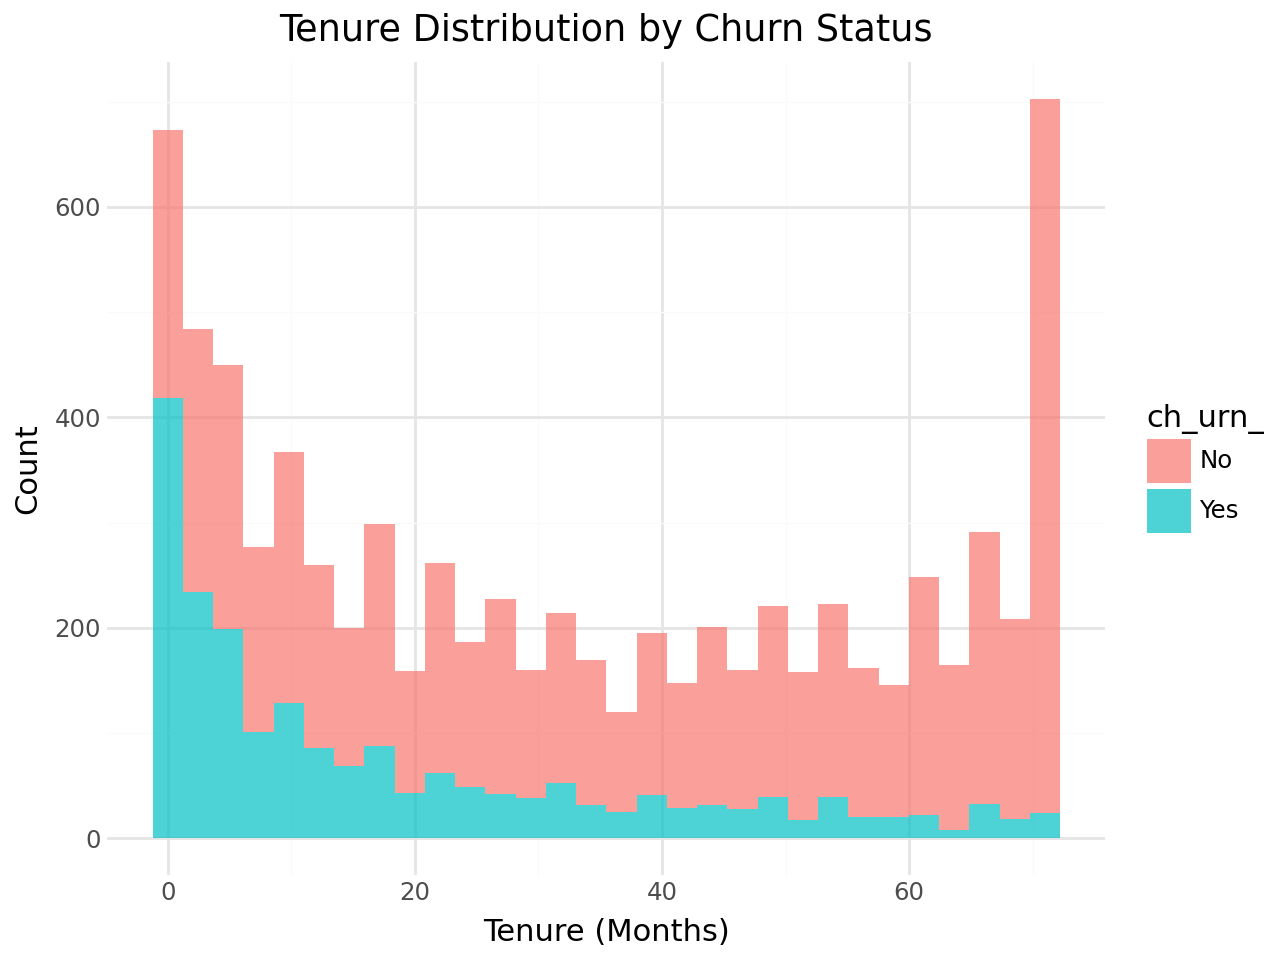

In [222]:
(ggplot(telco2, aes(x='tenure', fill='ch_urn_'))
 + geom_histogram(bins=30, alpha=0.7)
 + theme_minimal()
 + labs(title='Tenure Distribution by Churn Status', 
        x='Tenure (Months)', 
        y='Count')
)

##### As time goes on (tenure increases), the churn bars get shorter.

In summary, the company should focus on Contract Migration (moving month-to-month users to long-term plans) and Value Reinforcement for high-paying subscribers during their first 6 months of tenure.